DATASET KELAS B KELOMPOK 1

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Tambahan
import matplotlib.patches as mpatches
import numpy as np
# Kelas B: separator titik koma
df = pd.read_csv('/content/Kelas B_CO2 Emissions by Car.csv', sep=';')
df.columns = df.columns.str.strip()

print('Shape dataset:', df.shape)
print('Kolom:', df.columns.tolist())
df.head()

Shape dataset: (679, 10)
Kolom: ['MODEL_YEAR', 'MAKE', 'MODEL', 'VEHICLE CLASS', 'ENGINE_SIZE', 'CYLINDERS', 'TRANSMISSION', 'FUEL', 'FUEL_CONSUMPTION*', 'CO2_EMISSIONS']


,MODEL_YEAR,MAKE,MODEL,VEHICLE CLASS,ENGINE_SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL_CONSUMPTION*,CO2_EMISSIONS
0,2001,ACURA,1.7EL,COMPACT,1.7,4,A4,X,9.3,191
1,2001,ACURA,1.7EL,COMPACT,1.7,4,M5,X,8.9,191
2,2001,ACURA,3.2CL,COMPACT,3.2,6,AS5,Z,13.7,265
3,2001,ACURA,3.2TL,MID-SIZE,3.2,6,AS5,Z,13.8,267
4,2001,ACURA,3.5RL,MID-SIZE,3.5,6,A4,Z,15.0,301


Kategori A (Agregasi)

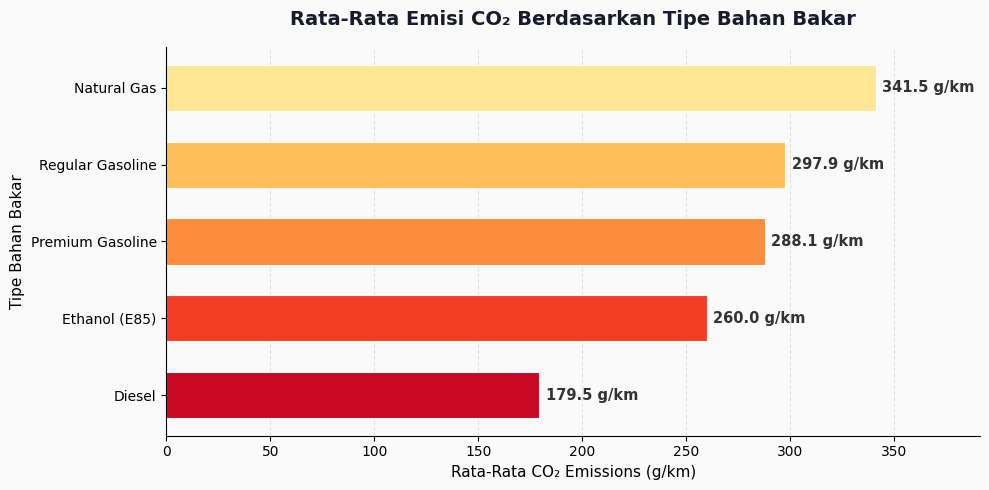

Grafik 1 (Kategori A) berhasil disimpan.


In [ ]:
# Mapping kode bahan bakar ke nama lengkap
fuel_map = {
    'X': 'Regular Gasoline',
    'Z': 'Premium Gasoline',
    'D': 'Diesel',
    'E': 'Ethanol (E85)',
    'N': 'Natural Gas',
}

# Agregasi rata-rata CO2 per tipe bahan bakar, diurutkan ascending
df_a = (
    df.groupby('FUEL')['CO2_EMISSIONS']
    .mean()
    .reset_index()
    .sort_values('CO2_EMISSIONS', ascending=True)
)
df_a['FUEL_LABEL'] = df_a['FUEL'].map(fuel_map).fillna(df_a['FUEL'])

palette_a = sns.color_palette('YlOrRd', len(df_a))[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

bars = ax.barh(
    df_a['FUEL_LABEL'],
    df_a['CO2_EMISSIONS'],
    color=palette_a,
    edgecolor='white',
    linewidth=0.8,
    height=0.6,
)

# Label nilai di ujung setiap bar
for bar, val in zip(bars, df_a['CO2_EMISSIONS']):
    ax.text(
        bar.get_width() + 3,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.1f} g/km',
        va='center', ha='left',
        fontsize=10.5, fontweight='bold', color='#333333'
    )

ax.set_title('Rata-Rata Emisi CO₂ Berdasarkan Tipe Bahan Bakar',
             fontsize=14, fontweight='bold', pad=16, color='#1a1a2e')
ax.set_xlabel('Rata-Rata CO₂ Emissions (g/km)', fontsize=11)
ax.set_ylabel('Tipe Bahan Bakar', fontsize=11)
ax.set_xlim(0, df_a['CO2_EMISSIONS'].max() + 50)
ax.xaxis.grid(True, linestyle='--', alpha=0.5, color='#cccccc')
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig('grafik1_kategori_A.png', dpi=180, bbox_inches='tight')
plt.show()
print('Grafik 1 (Kategori A) berhasil disimpan.')

Kategori B (Tren/Filter)

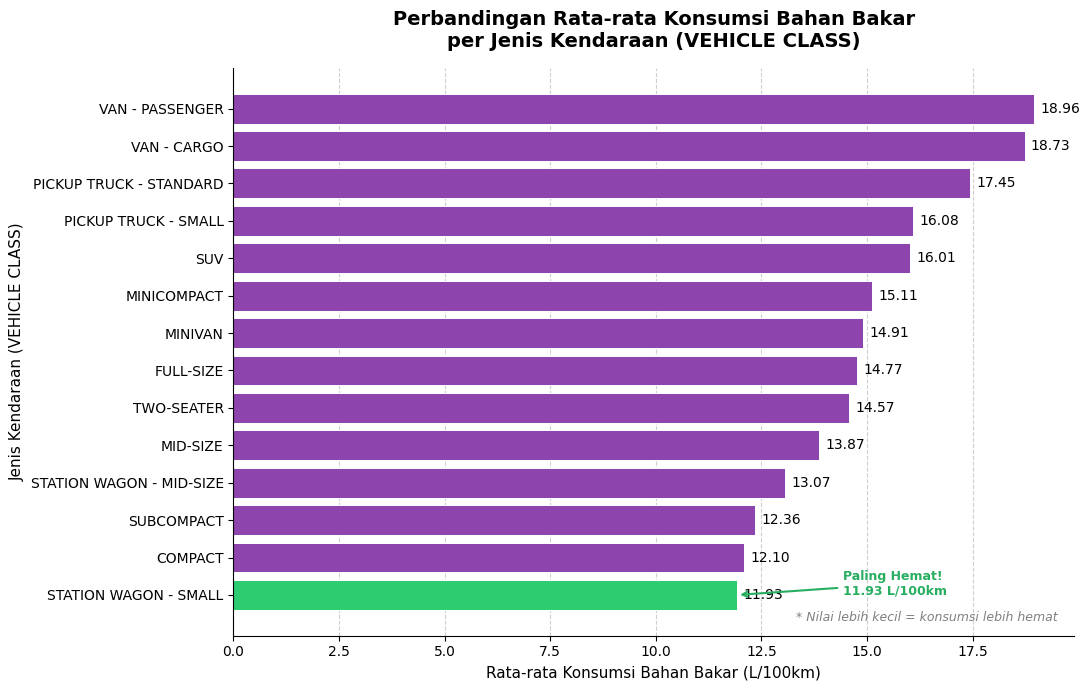

Grafik 2 (Kategori B) berhasil disimpan.


In [ ]:
# Hitung rata-rata konsumsi bahan bakar per kelas kendaraan
avg_fuel = (
    df.groupby('VEHICLE CLASS')['FUEL_CONSUMPTION*']
    .mean()
    .sort_values(ascending=True)   # ascending: terkecil = paling hemat
    .reset_index()
)
avg_fuel.columns = ['VEHICLE CLASS', 'AVG_FUEL_CONSUMPTION']
avg_fuel['AVG_FUEL_CONSUMPTION'] = avg_fuel['AVG_FUEL_CONSUMPTION'].round(2)

# Warna: bar paling hemat hijau, sisanya ungu
colors = ['#2ecc71' if i == 0 else '#8e44ad' for i in range(len(avg_fuel))]

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(
    avg_fuel['VEHICLE CLASS'],
    avg_fuel['AVG_FUEL_CONSUMPTION'],
    color=colors,
    edgecolor='white',
    linewidth=0.7
)

# Label nilai di ujung setiap bar
for bar, val in zip(bars, avg_fuel['AVG_FUEL_CONSUMPTION']):
    ax.text(
        bar.get_width() + 0.15,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.2f}',
        va='center', ha='left', fontsize=10, color='black'
    )

# Anotasi kendaraan paling hemat
most_efficient = avg_fuel.iloc[0]
ax.annotate(
    f"Paling Hemat!\n{most_efficient['AVG_FUEL_CONSUMPTION']} L/100km",
    xy=(most_efficient['AVG_FUEL_CONSUMPTION'], 0),
    xytext=(most_efficient['AVG_FUEL_CONSUMPTION'] + 2.5, 0),
    fontsize=9, color='#27ae60', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#27ae60', lw=1.5)
)

ax.set_title(
    'Perbandingan Rata-rata Konsumsi Bahan Bakar\nper Jenis Kendaraan (VEHICLE CLASS)',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Rata-rata Konsumsi Bahan Bakar (L/100km)', fontsize=11)
ax.set_ylabel('Jenis Kendaraan (VEHICLE CLASS)', fontsize=11)
ax.xaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.text(0.98, 0.02, '* Nilai lebih kecil = konsumsi lebih hemat',
        transform=ax.transAxes, fontsize=9,
        ha='right', va='bottom', style='italic', color='gray')

plt.tight_layout()
plt.savefig('grafik2_kategori_B.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik 2 (Kategori B) berhasil disimpan.')

Kategori C (Korelasi)

Nilai korelasi (r) ENGINE_SIZE vs CO2_EMISSIONS: 0.8506


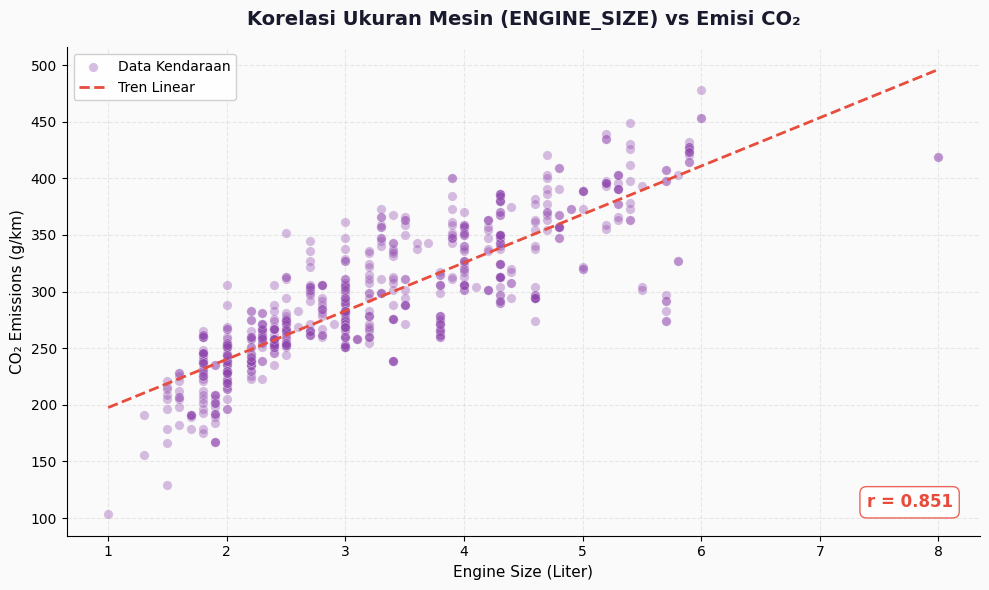

Grafik 3 (Kategori C) berhasil disimpan.


In [ ]:
corr_val = df['ENGINE_SIZE'].corr(df['CO2_EMISSIONS'])
print(f'Nilai korelasi (r) ENGINE_SIZE vs CO2_EMISSIONS: {corr_val:.4f}')

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

ax.scatter(
    df['ENGINE_SIZE'],
    df['CO2_EMISSIONS'],
    alpha=0.35,
    color='#8e44ad',
    edgecolors='white',
    linewidths=0.3,
    s=45,
    label='Data Kendaraan'
)

# Garis tren linear
z = np.polyfit(df['ENGINE_SIZE'], df['CO2_EMISSIONS'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['ENGINE_SIZE'].min(), df['ENGINE_SIZE'].max(), 200)
ax.plot(x_line, p(x_line), color='#e74c3c', linewidth=2,
        linestyle='--', label='Tren Linear', zorder=5)

ax.set_title('Korelasi Ukuran Mesin (ENGINE_SIZE) vs Emisi CO₂',
             fontsize=14, fontweight='bold', pad=16, color='#1a1a2e')
ax.set_xlabel('Engine Size (Liter)', fontsize=11)
ax.set_ylabel('CO₂ Emissions (g/km)', fontsize=11)

# Badge nilai korelasi
ax.text(
    0.97, 0.05, f'r = {corr_val:.3f}',
    transform=ax.transAxes, fontsize=12, fontweight='bold',
    ha='right', va='bottom', color='#e74c3c',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
              edgecolor='#e74c3c', alpha=0.85)
)

ax.legend(fontsize=10, framealpha=0.9)
ax.xaxis.grid(True, linestyle='--', alpha=0.4, color='#cccccc')
ax.yaxis.grid(True, linestyle='--', alpha=0.4, color='#cccccc')
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig('grafik3_kategori_C.png', dpi=180, bbox_inches='tight')
plt.show()
print('Grafik 3 (Kategori C) berhasil disimpan.')

Kategori D (Distribusi)

Jumlah data ACURA  : 11
Q1 = 222, Q3 = 304, IQR = 82
Lower Fence = 99.8, Upper Fence = 425.8
Jumlah outlier     : 0


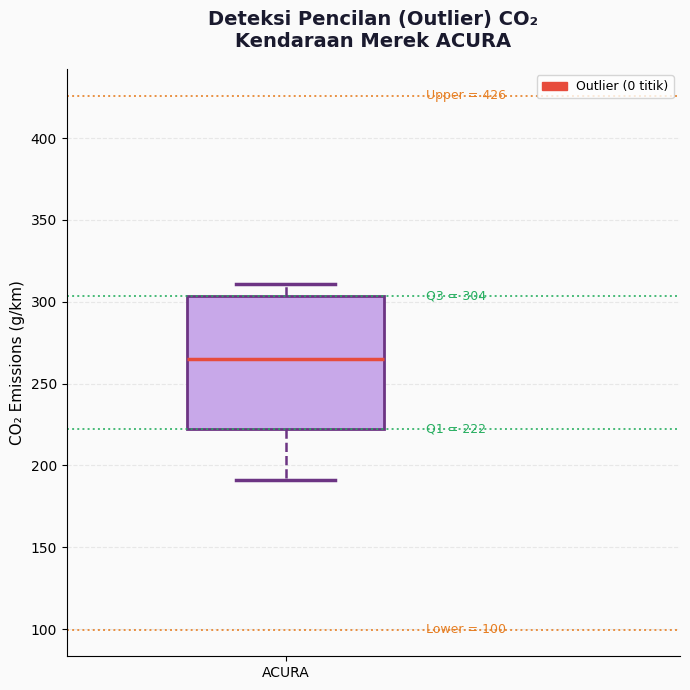

Grafik 4 (Kategori D) berhasil disimpan.


In [ ]:
data_acura = df[df['MAKE'] == 'ACURA']['CO2_EMISSIONS']

# Hitung statistik IQR
Q1 = data_acura.quantile(0.25)
Q3 = data_acura.quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

outliers_d = data_acura[(data_acura < lower_fence) | (data_acura > upper_fence)]
print(f'Jumlah data ACURA  : {len(data_acura)}')
print(f'Q1 = {Q1:.0f}, Q3 = {Q3:.0f}, IQR = {IQR:.0f}')
print(f'Lower Fence = {lower_fence:.1f}, Upper Fence = {upper_fence:.1f}')
print(f'Jumlah outlier     : {len(outliers_d)}')

fig, ax = plt.subplots(figsize=(7, 7))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

ax.boxplot(
    data_acura,
    patch_artist=True,
    widths=0.45,
    boxprops=dict(facecolor='#c8a8e9', color='#6c3483', linewidth=2),
    medianprops=dict(color='#e74c3c', linewidth=2.5),
    whiskerprops=dict(color='#6c3483', linewidth=1.8, linestyle='--'),
    capprops=dict(color='#6c3483', linewidth=2.5),
    flierprops=dict(marker='o', markerfacecolor='#e74c3c', markersize=8,
                    markeredgecolor='#922b21', markeredgewidth=0.8)
)

# Garis referensi statistik
ref_lines = [
    (Q1,          f'Q1 = {Q1:.0f}',           '#27ae60'),
    (Q3,          f'Q3 = {Q3:.0f}',           '#27ae60'),
    (lower_fence, f'Lower = {lower_fence:.0f}', '#e67e22'),
    (upper_fence, f'Upper = {upper_fence:.0f}', '#e67e22'),
]
for y_val, label, color in ref_lines:
    ax.axhline(y_val, linestyle=':', linewidth=1.4, color=color, alpha=0.85)
    ax.text(1.32, y_val, label, fontsize=9, color=color, va='center')

# Anotasi nilai outlier
for val in outliers_d:
    ax.annotate(
        f'{val:.0f} g/km',
        xy=(1, val), xytext=(1.18, val),
        fontsize=9, color='#e74c3c', fontweight='bold',
        arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.3)
    )

ax.set_title('Deteksi Pencilan (Outlier) CO₂\nKendaraan Merek ACURA',
             fontsize=14, fontweight='bold', pad=16, color='#1a1a2e')
ax.set_ylabel('CO₂ Emissions (g/km)', fontsize=11)
ax.set_xticks([1])
ax.set_xticklabels(['ACURA'], fontsize=11)
ax.set_xlim(0.5, 1.9)
ax.yaxis.grid(True, linestyle='--', alpha=0.4, color='#cccccc')
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(labelsize=10)

red_patch = mpatches.Patch(color='#e74c3c', label=f'Outlier ({len(outliers_d)} titik)')
ax.legend(handles=[red_patch], fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('grafik4_kategori_D.png', dpi=180, bbox_inches='tight')
plt.show()
print('Grafik 4 (Kategori D) berhasil disimpan.')

Kategori E

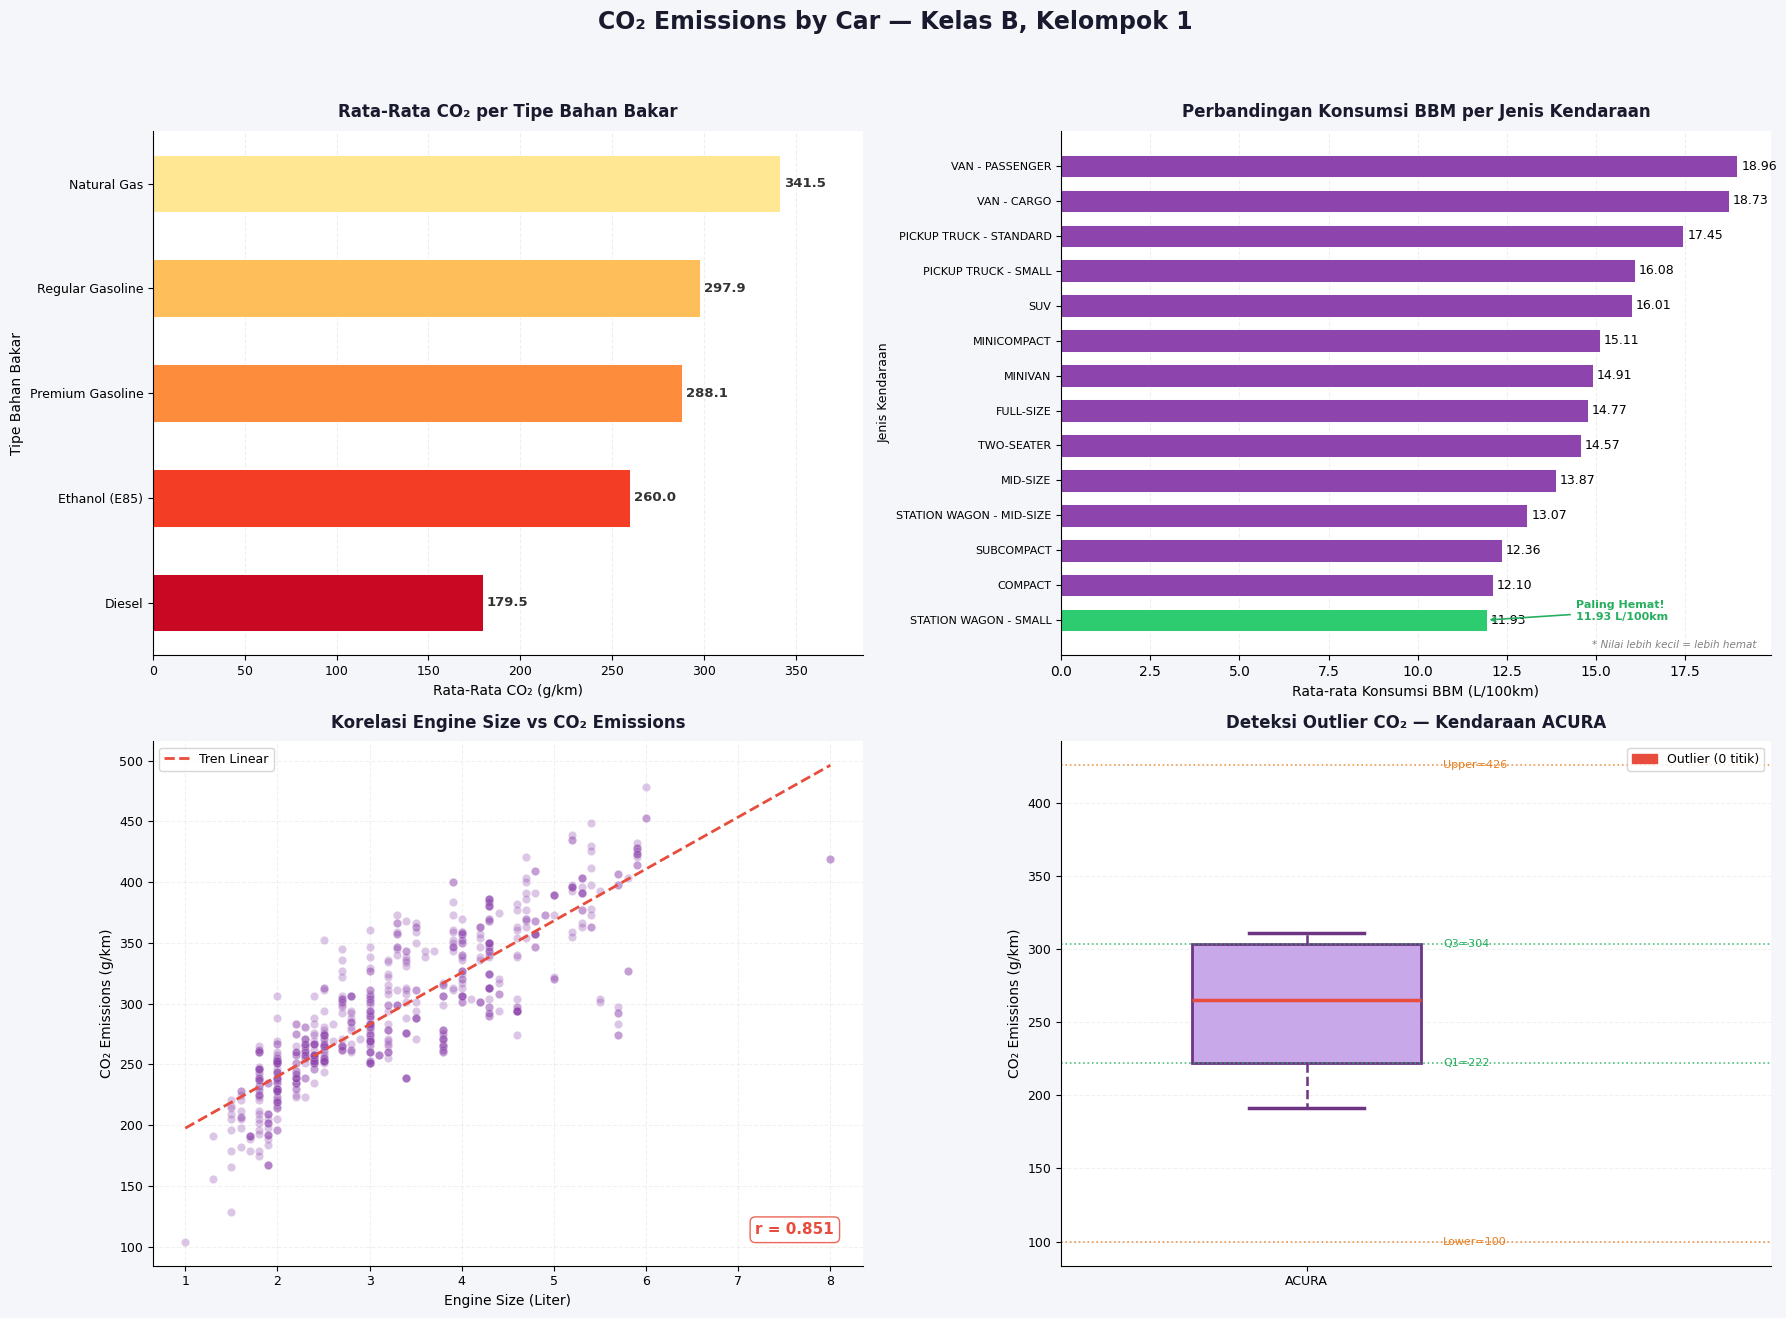

Grafik 5 (Gabungan) berhasil disimpan.


In [ ]:
# ── Persiapan data untuk semua subplot ──────────────────────────────────

# Data A: rata-rata CO2 per bahan bakar
fuel_map = {'X':'Regular Gasoline','Z':'Premium Gasoline','D':'Diesel',
            'E':'Ethanol (E85)','N':'Natural Gas'}
df_a = (df.groupby('FUEL')['CO2_EMISSIONS'].mean().reset_index()
          .sort_values('CO2_EMISSIONS', ascending=True))
df_a['FUEL_LABEL'] = df_a['FUEL'].map(fuel_map).fillna(df_a['FUEL'])
palette_a = sns.color_palette('YlOrRd', len(df_a))[::-1]

# Data B: konsumsi BBM per kelas kendaraan
df_b = (df.groupby('VEHICLE CLASS')['FUEL_CONSUMPTION*'].mean()
          .sort_values(ascending=True).reset_index())
colors_b = ['#2ecc71' if i == 0 else '#8e44ad' for i in range(len(df_b))]

# Data C: korelasi
corr_val = df['ENGINE_SIZE'].corr(df['CO2_EMISSIONS'])

# Data D: distribusi ACURA
data_d = df[df['MAKE'] == 'ACURA']['CO2_EMISSIONS']
Q1d = data_d.quantile(0.25); Q3d = data_d.quantile(0.75)
IQRd = Q3d - Q1d
lfd  = Q1d - 1.5*IQRd; ufd = Q3d + 1.5*IQRd
n_out = len(data_d[(data_d < lfd) | (data_d > ufd)])

# ── Inisialisasi figure ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.patch.set_facecolor('#F4F6F9')
for ax_sub in axes.flat:
    ax_sub.set_facecolor('#FFFFFF')

fig.suptitle('CO₂ Emissions by Car — Kelas B, Kelompok 1',
             fontsize=17, fontweight='bold', color='#1a1a2e', y=1.01)

# ── axes[0,0] — Grafik A ─────────────────────────────────────────────────
ax_a = axes[0, 0]
bars_a = ax_a.barh(df_a['FUEL_LABEL'], df_a['CO2_EMISSIONS'],
                   color=palette_a, edgecolor='white', linewidth=0.7, height=0.55)
for bar, val in zip(bars_a, df_a['CO2_EMISSIONS']):
    ax_a.text(bar.get_width()+2, bar.get_y()+bar.get_height()/2,
              f'{val:.1f}', va='center', ha='left', fontsize=9.5, fontweight='bold', color='#333')
ax_a.set_title('Rata-Rata CO₂ per Tipe Bahan Bakar',
               fontsize=12, fontweight='bold', pad=10, color='#1a1a2e')
ax_a.set_xlabel('Rata-Rata CO₂ (g/km)', fontsize=10)
ax_a.set_ylabel('Tipe Bahan Bakar', fontsize=10)
ax_a.set_xlim(0, df_a['CO2_EMISSIONS'].max()+45)
ax_a.xaxis.grid(True, linestyle='--', alpha=0.45, color='#ddd')
ax_a.set_axisbelow(True)
ax_a.spines[['top','right']].set_visible(False)
ax_a.tick_params(labelsize=9)

# ── axes[0,1] — Grafik B ─────────────────────────────────────────────────
ax_b = axes[0, 1]
bars_b = ax_b.barh(df_b['VEHICLE CLASS'], df_b['FUEL_CONSUMPTION*'],
                   color=colors_b, edgecolor='white', linewidth=0.7, height=0.65)
for bar, val in zip(bars_b, df_b['FUEL_CONSUMPTION*']):
    ax_b.text(bar.get_width()+0.12, bar.get_y()+bar.get_height()/2,
              f'{val:.2f}', va='center', ha='left', fontsize=9, color='black')
most_eff = df_b.iloc[0]
ax_b.annotate(
    f"Paling Hemat!\n{most_eff['FUEL_CONSUMPTION*']:.2f} L/100km",
    xy=(most_eff['FUEL_CONSUMPTION*'], 0), xytext=(most_eff['FUEL_CONSUMPTION*']+2.5, 0),
    fontsize=8, color='#27ae60', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#27ae60', lw=1.2)
)
ax_b.set_title('Perbandingan Konsumsi BBM per Jenis Kendaraan',
               fontsize=12, fontweight='bold', pad=10, color='#1a1a2e')
ax_b.set_xlabel('Rata-rata Konsumsi BBM (L/100km)', fontsize=10)
ax_b.set_ylabel('Jenis Kendaraan', fontsize=9)
ax_b.xaxis.grid(True, linestyle='--', alpha=0.45, color='#ddd')
ax_b.set_axisbelow(True)
ax_b.spines[['top','right']].set_visible(False)
ax_b.tick_params(axis='y', labelsize=8)
ax_b.text(0.98, 0.01, '* Nilai lebih kecil = lebih hemat',
          transform=ax_b.transAxes, fontsize=7.5, ha='right', va='bottom',
          style='italic', color='gray')

# ── axes[1,0] — Grafik C ─────────────────────────────────────────────────
ax_c = axes[1, 0]
ax_c.scatter(df['ENGINE_SIZE'], df['CO2_EMISSIONS'],
             alpha=0.3, color='#8e44ad', edgecolors='white', linewidths=0.2, s=35)
z2 = np.polyfit(df['ENGINE_SIZE'], df['CO2_EMISSIONS'], 1)
p2 = np.poly1d(z2)
x2 = np.linspace(df['ENGINE_SIZE'].min(), df['ENGINE_SIZE'].max(), 200)
ax_c.plot(x2, p2(x2), color='#e74c3c', linewidth=2, linestyle='--', label='Tren Linear')
ax_c.set_title('Korelasi Engine Size vs CO₂ Emissions',
               fontsize=12, fontweight='bold', pad=10, color='#1a1a2e')
ax_c.set_xlabel('Engine Size (Liter)', fontsize=10)
ax_c.set_ylabel('CO₂ Emissions (g/km)', fontsize=10)
ax_c.text(0.96, 0.06, f'r = {corr_val:.3f}', transform=ax_c.transAxes,
          fontsize=11, fontweight='bold', ha='right', color='#e74c3c',
          bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#e74c3c', alpha=0.85))
ax_c.legend(fontsize=9)
ax_c.xaxis.grid(True, linestyle='--', alpha=0.4, color='#ddd')
ax_c.yaxis.grid(True, linestyle='--', alpha=0.4, color='#ddd')
ax_c.set_axisbelow(True)
ax_c.spines[['top','right']].set_visible(False)
ax_c.tick_params(labelsize=9)

# ── axes[1,1] — Grafik D ─────────────────────────────────────────────────
ax_d = axes[1, 1]
ax_d.boxplot(
    data_d, patch_artist=True, widths=0.42,
    boxprops=dict(facecolor='#c8a8e9', color='#6c3483', linewidth=2),
    medianprops=dict(color='#e74c3c', linewidth=2.5),
    whiskerprops=dict(color='#6c3483', linewidth=1.8, linestyle='--'),
    capprops=dict(color='#6c3483', linewidth=2.5),
    flierprops=dict(marker='o', markerfacecolor='#e74c3c', markersize=6,
                    markeredgecolor='#922b21', markeredgewidth=0.6)
)
for y_val, label, color in [(Q1d, f'Q1={Q1d:.0f}', '#27ae60'),
                              (Q3d, f'Q3={Q3d:.0f}', '#27ae60'),
                              (ufd,  f'Upper={ufd:.0f}',  '#e67e22'),
                              (lfd,  f'Lower={lfd:.0f}',  '#e67e22')]:
    ax_d.axhline(y_val, linestyle=':', linewidth=1.2, color=color, alpha=0.8)
    ax_d.text(1.25, y_val, label, fontsize=8, color=color, va='center')
ax_d.set_title('Deteksi Outlier CO₂ — Kendaraan ACURA',
               fontsize=12, fontweight='bold', pad=10, color='#1a1a2e')
ax_d.set_ylabel('CO₂ Emissions (g/km)', fontsize=10)
ax_d.set_xticks([1]); ax_d.set_xticklabels(['ACURA'], fontsize=10)
ax_d.set_xlim(0.55, 1.85)
ax_d.yaxis.grid(True, linestyle='--', alpha=0.4, color='#ddd')
ax_d.set_axisbelow(True)
ax_d.spines[['top','right']].set_visible(False)
ax_d.tick_params(labelsize=9)
ax_d.legend(handles=[mpatches.Patch(color='#e74c3c', label=f'Outlier ({n_out} titik)')],
            fontsize=9, loc='upper right')

# ── Simpan ───────────────────────────────────────────────────────────────
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig('grafik5_gabungan.png', dpi=180, bbox_inches='tight')
plt.show()
print('Grafik 5 (Gabungan) berhasil disimpan.')